/Users/ivanaphanasyev/l/vins-rnd/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


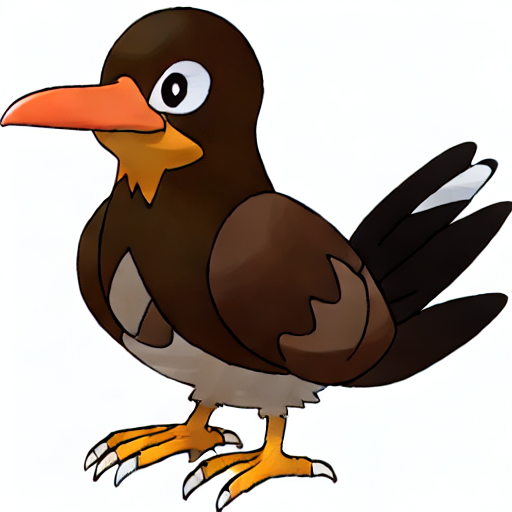

In [2]:
from datasets import load_dataset

ds = load_dataset("huggingface/documentation-images")
image = ds["train"][1]["image"].copy()
image

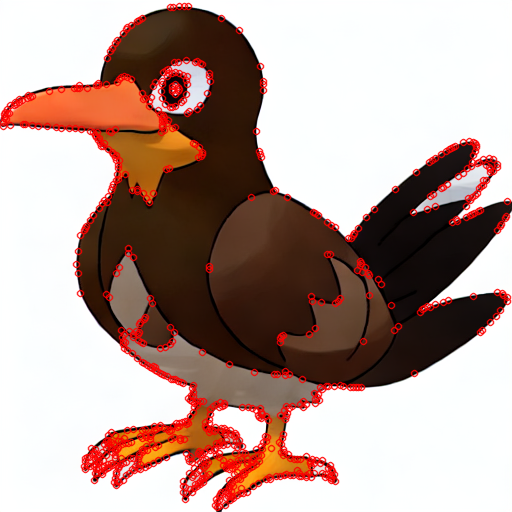

In [4]:
import cv2 as cv
import numpy as np
from PIL import Image

img = np.array(image)
# Create a mask (e.g., a white rectangle in the center of a black image)

# Initiate FAST object
fast = cv.FastFeatureDetector_create()

# Detect keypoints within the mask
keypoints = fast.detect(img)

# Draw the keypoints
img_keypoints = cv.drawKeypoints(img, keypoints, None, color=(255, 0, 0))
# Display the result (or save)
Image.fromarray(img_keypoints)

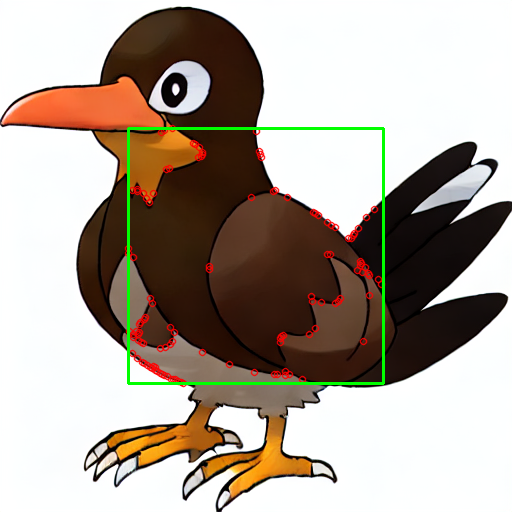

In [20]:
import numpy as np
from PIL import Image

img = np.array(image)
# Create a mask (e.g., a white rectangle in the center of a black image)

# Initiate FAST object
fast = cv.FastFeatureDetector_create()

# Center ROI mask: 25%..75% of image height/width
h, w = img.shape[:2]
y0, y1 = int(0.25 * h), int(0.75 * h)
x0, x1 = int(0.25 * w), int(0.75 * w)

# OpenCV expects a single-channel 8-bit mask
mask = np.zeros((h, w), dtype=np.uint8)
mask[y0:y1, x0:x1] = 255  # Define the ROI

# Detect keypoints within the mask
keypoints = fast.detect(img, mask=mask)

# Draw the keypoints
img_keypoints = cv.drawKeypoints(img, keypoints, None, color=(255, 0, 0))

# Draw the mask ROI rectangle (25%..75%)
img_keypoints = cv.rectangle(
    img_keypoints,
    (x0, y0),
    (x1 - 1, y1 - 1),
    color=(0, 255, 0),
    thickness=2,
)

img_masked = cv.line(img, (100, 100), (400, 400), (255, 0, 0), 2)
# Display the result (or save)
Image.fromarray(img_keypoints)